In [1]:
import sys, os, time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display, HTML

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root / 'common' / 'scripts'))
from generate_charts import setup_plot_style, TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE

setup_plot_style()

# Report-specific color scheme
COMPETITOR_COLORS = {
    'Tuleva': TULEVA_BLUE,
    'Swedbank': '#FF8C00',   # orange
    'LHV': '#8B4513',        # brown
    'SEB': '#51c26c',        # green
    'Luminor': '#7B2D8E',    # violet
}

# Load Tuleva CSS for HTML output
css_path = project_root / 'common' / 'branding' / 'style.css'
display(HTML(f'<link rel="stylesheet" href="{css_path}">'))

print("Setup complete")

Setup complete


In [2]:
FUNDS = {
    # Tuleva
    'EE3600109435': {'name': 'Tuleva Maailma Aktsiate Pensionifond', 'short': 'Tuleva Aktsiad', 'manager': 'Tuleva', 'category': 'index'},
    'EE3600109443': {'name': 'Tuleva Maailma Võlakirjade Pensionifond', 'short': 'Tuleva Võlakirjad', 'manager': 'Tuleva', 'category': 'bond'},
    # LHV
    'EE3600019832': {'name': 'LHV Pensionifond Ettevõtlik',  'short': 'LHV Ettevõtlik',  'manager': 'LHV', 'category': 'active'},
    'EE3600109401': {'name': 'LHV Pensionifond Indeks',      'short': 'LHV Indeks',      'manager': 'LHV', 'category': 'index'},
    'EE3600019766': {'name': 'LHV Pensionifond Julge',       'short': 'LHV Julge',       'manager': 'LHV', 'category': 'active'},
    'EE3600019782': {'name': 'LHV Pensionifond Rahulik',     'short': 'LHV Rahulik',     'manager': 'LHV', 'category': 'conservative'},
    'EE3600019774': {'name': 'LHV Pensionifond Tasakaalukas', 'short': 'LHV Tasakaalukas', 'manager': 'LHV', 'category': 'active'},
    'EE3600109476': {'name': 'LHV Pensionifond Eesti',       'short': 'LHV Eesti',       'manager': 'LHV', 'category': 'active'},      # discontinued 2020-08
    'EE3600019824': {'name': 'LHV Pensionifond S',           'short': 'LHV S',           'manager': 'LHV', 'category': 'active'},      # discontinued 2025-09
    'EE3600001723': {'name': 'LHV Pensionifond Roheline',    'short': 'LHV Roheline',    'manager': 'LHV', 'category': 'active'},      # discontinued 2025-09
    # SEB
    'EE3600001699': {'name': 'SEB pensionifond 18+',    'short': 'SEB 18+',    'manager': 'SEB', 'category': 'active'},
    'EE3600019725': {'name': 'SEB pensionifond 55+',    'short': 'SEB 55+',    'manager': 'SEB', 'category': 'active'},
    'EE3600098612': {'name': 'SEB pensionifond 60+',    'short': 'SEB 60+',    'manager': 'SEB', 'category': 'mixed'},
    'EE3600019717': {'name': 'SEB pensionifond 65+',    'short': 'SEB 65+',    'manager': 'SEB', 'category': 'conservative'},
    'EE3600109427': {'name': 'SEB pensionifond indeks', 'short': 'SEB Indeks', 'manager': 'SEB', 'category': 'index'},
    'EE3600103297': {'name': 'SEB Energiline Pensionifond', 'short': 'SEB Energiline', 'manager': 'SEB', 'category': 'active'},  # discontinued 2024-01
    # Swedbank
    'EE3600001814': {'name': 'Swedbank Pensionifond Indeks',                      'short': 'Swedbank Indeks',  'manager': 'Swedbank', 'category': 'index'},
    'EE3600019741': {'name': 'Swedbanki pensionifond 1960-69 sündinutele',        'short': 'Swedbank K1960',   'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600019758': {'name': 'Swedbanki pensionifond 1970-79 sündinutele',        'short': 'Swedbank K1970',   'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600103248': {'name': 'Swedbanki pensionifond 1980-89 sündinutele',        'short': 'Swedbank K1980',   'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600001848': {'name': 'Swedbanki pensionifond 2000-09 sündinutele',        'short': 'Swedbank 2000-09', 'manager': 'Swedbank', 'category': 'mixed'},
    'EE3600109393': {'name': 'Swedbanki pensionifond indeks 1990-99 sündinutele', 'short': 'Swedbank K1990',   'manager': 'Swedbank', 'category': 'index'},
    'EE3600019733': {'name': 'Swedbanki pensionifond Konservatiivne',             'short': 'Swedbank Kons.',   'manager': 'Swedbank', 'category': 'conservative'},
    # Luminor
    'EE3600103503': {'name': 'Luminor 16-50 pensionifond',  'short': 'Luminor 16-50',  'manager': 'Luminor', 'category': 'mixed'},
    'EE3600098430': {'name': 'Luminor 50-56 pensionifond',  'short': 'Luminor 50-56',  'manager': 'Luminor', 'category': 'mixed'},
    'EE3600098448': {'name': 'Luminor 56+ pensionifond',    'short': 'Luminor 56+',    'manager': 'Luminor', 'category': 'mixed'},
    'EE3600098455': {'name': 'Luminor 61-65 pensionifond',  'short': 'Luminor 61-65',  'manager': 'Luminor', 'category': 'conservative'},
    'EE3600001806': {'name': 'Luminor Indeks Pensionifond', 'short': 'Luminor Indeks', 'manager': 'Luminor', 'category': 'index'},
}

print(f"Defined {len(FUNDS)} funds")

Defined 28 funds


In [3]:
CACHE_FILE = Path('data/ii_pillar_contributions.csv')
API_URL = 'https://www.pensionikeskus.ee/ws/et/stats/receipt-statistics'

if CACHE_FILE.exists():
    df = pd.read_csv(CACHE_FILE, parse_dates=['period_start'])
    print(f"Loaded {len(df)} rows from cache ({df['period_start'].min():%Y-%m} to {df['period_start'].max():%Y-%m})")
else:
    # Fetch periods list
    resp = requests.get(API_URL)
    resp.raise_for_status()
    data = resp.json()['data']
    
    periods = [p for p in data['periods'] if p['start_date'] >= '2020-01-01']
    periods.sort(key=lambda p: p['start_date'])
    print(f"Fetching {len(periods)} months: {periods[0]['start_date'][:7]} to {periods[-1]['start_date'][:7]}")
    
    rows = []
    for i, period in enumerate(periods):
        if i > 0:
            time.sleep(0.3)
            resp = requests.get(API_URL, params={'period': period['id']})
            resp.raise_for_status()
            pdata = resp.json()['data']
        else:
            # First period — need to fetch since default is latest month
            resp = requests.get(API_URL, params={'period': period['id']})
            resp.raise_for_status()
            pdata = resp.json()['data']
        
        for s in pdata['stats']:
            if s['type'] != 'F':
                continue
            rows.append({
                'period_start': period['start_date'],
                'isin': s['isin_pik'],
                'api_name': s['name'],
                'amount': s['amount'],
                'individuals': s['individuals_count'],
                'count': s['count'],
            })
        
        if (i + 1) % 20 == 0:
            print(f"  ... {i + 1}/{len(periods)} months fetched")
    
    print(f"  ... {len(periods)}/{len(periods)} months fetched")
    df = pd.DataFrame(rows)
    df['period_start'] = pd.to_datetime(df['period_start'])
    
    # Save cache
    CACHE_FILE.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE_FILE, index=False)
    print(f"Saved {len(df)} rows to {CACHE_FILE}")

# Enrich with fund metadata
fund_meta = pd.DataFrame.from_dict(FUNDS, orient='index').reset_index().rename(columns={'index': 'isin'})
df = df.merge(fund_meta, on='isin', how='left')

# Check for unknown ISINs
unknown = df[df['manager'].isna()]['isin'].unique()
if len(unknown):
    print(f"WARNING: Unknown ISINs (not in FUNDS dict): {unknown}")
    df = df[df['manager'].notna()]

df['year'] = df['period_start'].dt.year
df['month'] = df['period_start'].dt.month

print(f"\nDataset: {df['period_start'].min():%Y-%m} to {df['period_start'].max():%Y-%m}, {df['isin'].nunique()} funds, {len(df)} rows")

Fetching 78 months: 2020-01 to 2026-06


  ... 20/78 months fetched


  ... 40/78 months fetched


  ... 60/78 months fetched


  ... 78/78 months fetched
Saved 1989 rows to data/ii_pillar_contributions.csv

Dataset: 2020-01 to 2026-06, 28 funds, 1989 rows


In [4]:
# Remove periods distorted by II pillar state contribution suspension.
# Jul 2020 – Oct 2021: state withheld ~2/3 of contributions.
# Jan 2023: one-off lump-sum compensation for withheld amounts.
# These periods are excluded from analysis; gaps show naturally in charts.

EXCLUDE_START = pd.Timestamp('2020-07-01')
EXCLUDE_END = pd.Timestamp('2021-10-01')
COMPENSATE = pd.Timestamp('2023-01-01')

n_before = len(df)
df = df[~(
    ((df['period_start'] >= EXCLUDE_START) & (df['period_start'] <= EXCLUDE_END)) |
    (df['period_start'] == COMPENSATE)
)]
print(f"Removed {n_before - len(df)} rows ({(n_before - len(df)) // df['isin'].nunique()} months excluded)")

Removed 417 rows (14 months excluded)


# II samba sissemaksete analüüs

Andmed: [Pensionikeskus](https://www.pensionikeskus.ee/statistika/ii-sammas/ii-samba-sissemaksete-ulevaade/), jaanuar 2020 – juuni 2026.

Analüüs tehtud [Claude Code](https://claude.ai/claude-code) abiga 1. aprillil 2026, umbes 2 tunniga algsest ideest valmis raportini. Andmed uuendatud juulis 2026.

**NB:** Juulist 2020 kuni oktoobrini 2021 peatas riik oma osa (~2/3) II samba sissemaksetest. Peatatud sissemaksed kompenseeriti ühekordse maksena jaanuaris 2023. Need kuud on analüüsist välja jäetud.

## Sissemaksed fondide kaupa

Peamine trend: indeksfondide (sinisega) osakaal sissemaksetes kasvab iga fondihalduri juures. Indeksfondide osakaal halduri sissemaksetes (I kv 2020 → II kv 2026):

- **SEB:** 5% → 46%
- **Swedbank:** 2% → 43% (sh Swedbank K1990 indeksfond)
- **LHV:** 5% → 28%
- **Luminor:** 0% → 8%
- **Tuleva** on 100% indeksfondid ja turuosa on kasvanud 4% → 16%

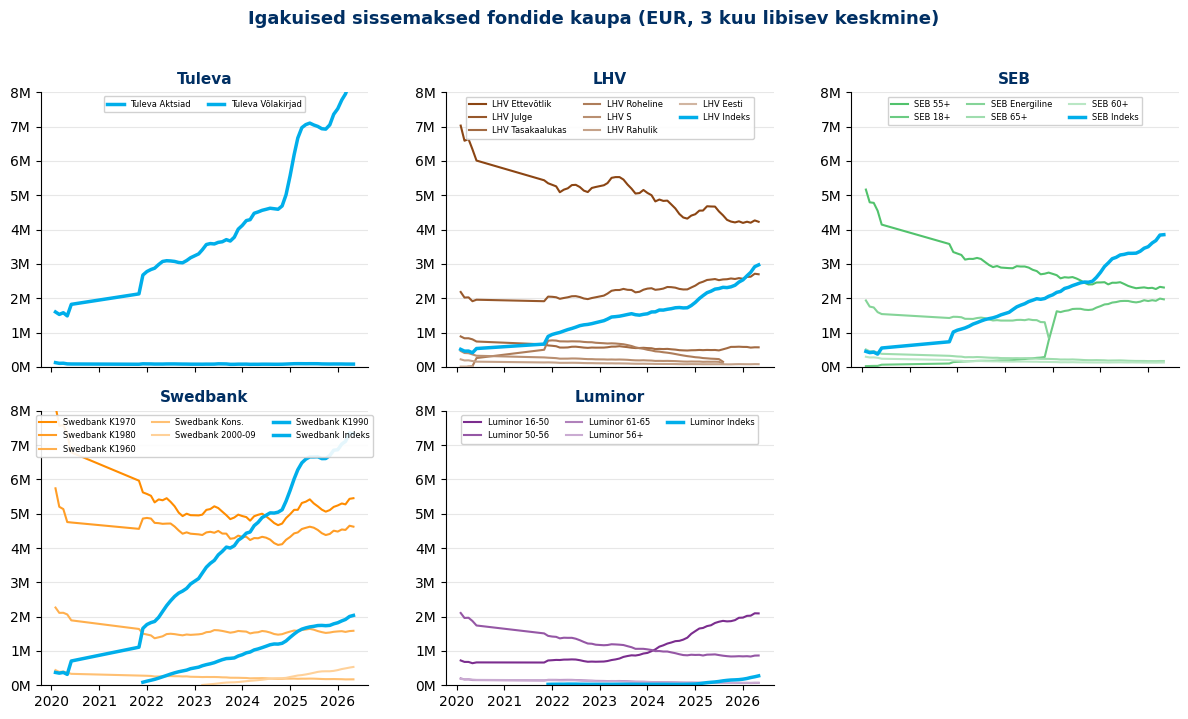

In [5]:
MANAGER_ORDER = ['Tuleva', 'LHV', 'SEB', 'Swedbank', 'Luminor']
ROLLING_WINDOW = 3
FB_SIZE = (10, 5.25)  # ~1200x630px at 120dpi

# Generate shade variants for each manager's funds (excluding index funds which get blue)
def get_fund_colors(manager, n):
    """Return n shades based on manager's brand color."""
    import matplotlib.colors as mcolors
    base = COMPETITOR_COLORS[manager]
    rgb = mcolors.to_rgb(base)
    colors = []
    for i in range(n):
        factor = 0.4 + 0.6 * (i / max(n - 1, 1))
        colors.append(tuple(1 - factor * (1 - c) for c in rgb))
    return colors[::-1]  # darkest first

INDEX_HIGHLIGHT = TULEVA_BLUE  # blue for all index funds

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
axes_flat = axes.flatten()
Y_MAX = 8  # millions EUR

for idx, manager in enumerate(MANAGER_ORDER):
    ax = axes_flat[idx]
    mdf_mgr = df[df['manager'] == manager].copy()
    funds = mdf_mgr.groupby('short')['amount'].sum().sort_values(ascending=False).index.tolist()
    
    # Split into index and non-index funds
    index_funds = [f for f in funds if mdf_mgr[mdf_mgr['short'] == f]['category'].iloc[0] in ('index', 'bond')]
    other_funds = [f for f in funds if f not in index_funds]
    other_colors = get_fund_colors(manager, max(len(other_funds), 1))
    
    for i, fund in enumerate(other_funds):
        fdf = mdf_mgr[mdf_mgr['short'] == fund].sort_values('period_start')
        smoothed = fdf['amount'].rolling(ROLLING_WINDOW, center=True).mean()
        ax.plot(fdf['period_start'], smoothed / 1e6, label=fund, color=other_colors[i], linewidth=1.5)
    
    for fund in index_funds:
        fdf = mdf_mgr[mdf_mgr['short'] == fund].sort_values('period_start')
        smoothed = fdf['amount'].rolling(ROLLING_WINDOW, center=True).mean()
        ax.plot(fdf['period_start'], smoothed / 1e6, label=fund, color=INDEX_HIGHLIGHT, linewidth=2.5)
    
    ax.set_title(manager, fontsize=11, fontweight='bold', color=TULEVA_NAVY)
    ax.set_ylim(0, Y_MAX)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}M'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=6, loc='upper center', framealpha=0.9, ncol=3)

axes_flat[5].set_visible(False)

fig.suptitle('Igakuised sissemaksed fondide kaupa (EUR, 3 kuu libisev keskmine)', fontsize=13, fontweight='bold', color=TULEVA_NAVY, y=1.02)
fig.tight_layout()
plt.show()

Sama trend on näha ka isikute arvus. Indeksfondi valinud isikute osakaal halduri sees (I kv 2020 → II kv 2026):

- **SEB:** 4% → 43%
- **Swedbank:** 3% → 41% (sh Swedbank K1990)
- **LHV:** 4% → 28%
- **Luminor:** 0% → 12%
- **Tuleva** turuosa isikute arvus: 3% → 10%

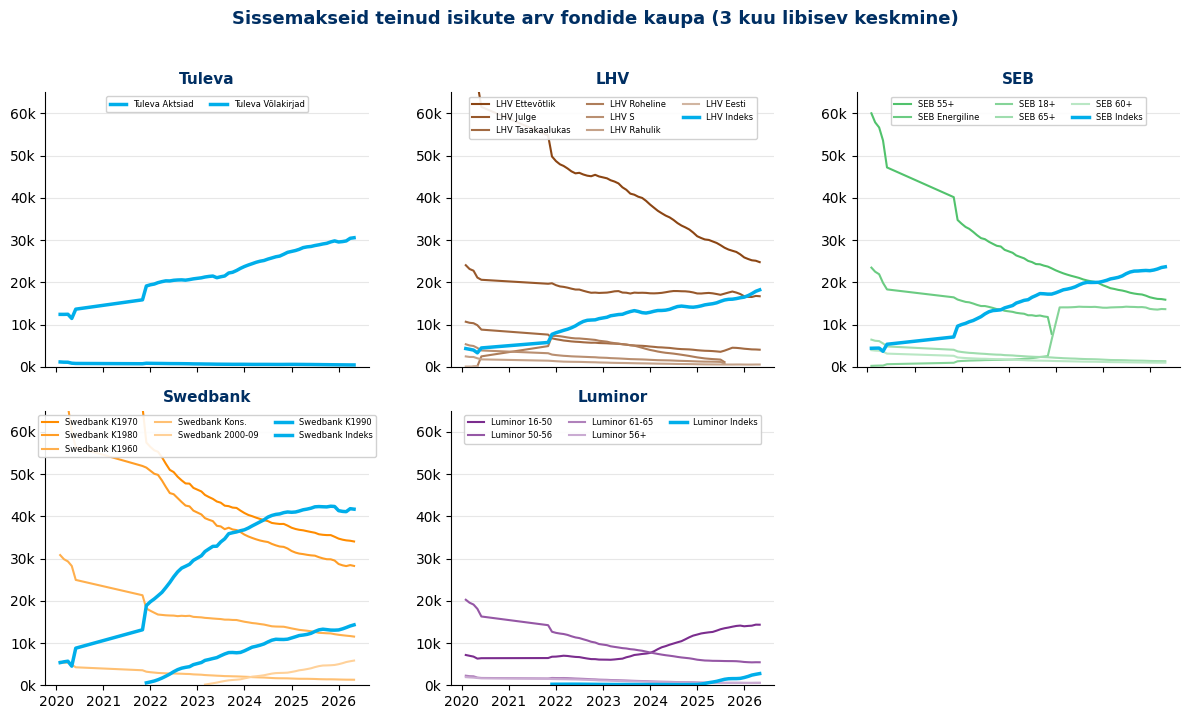

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
axes_flat = axes.flatten()
Y_MAX_IND = 65  # thousands

for idx, manager in enumerate(MANAGER_ORDER):
    ax = axes_flat[idx]
    mdf_mgr = df[df['manager'] == manager].copy()
    funds = mdf_mgr.groupby('short')['individuals'].sum().sort_values(ascending=False).index.tolist()
    
    # Split into index and non-index funds
    index_funds = [f for f in funds if mdf_mgr[mdf_mgr['short'] == f]['category'].iloc[0] in ('index', 'bond')]
    other_funds = [f for f in funds if f not in index_funds]
    other_colors = get_fund_colors(manager, max(len(other_funds), 1))
    
    for i, fund in enumerate(other_funds):
        fdf = mdf_mgr[mdf_mgr['short'] == fund].sort_values('period_start')
        smoothed = fdf['individuals'].rolling(ROLLING_WINDOW, center=True).mean()
        ax.plot(fdf['period_start'], smoothed / 1000, label=fund, color=other_colors[i], linewidth=1.5)
    
    for fund in index_funds:
        fdf = mdf_mgr[mdf_mgr['short'] == fund].sort_values('period_start')
        smoothed = fdf['individuals'].rolling(ROLLING_WINDOW, center=True).mean()
        ax.plot(fdf['period_start'], smoothed / 1000, label=fund, color=INDEX_HIGHLIGHT, linewidth=2.5)
    
    ax.set_title(manager, fontsize=11, fontweight='bold', color=TULEVA_NAVY)
    ax.set_ylim(0, Y_MAX_IND)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}k'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator())
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=6, loc='upper center', framealpha=0.9, ncol=3)

axes_flat[5].set_visible(False)

fig.suptitle('Sissemakseid teinud isikute arv fondide kaupa (3 kuu libisev keskmine)', fontsize=13, fontweight='bold', color=TULEVA_NAVY, y=1.02)
fig.tight_layout()
plt.show()

## Tuleva vs indeksfondid vs ülejäänud

In [7]:
# Define groups
def assign_group(row):
    if row['manager'] == 'Tuleva':
        return 'Tuleva'
    if row['category'] == 'index':
        return 'Muud indeksfondid'
    return f"{row['manager']} (muu)"

df['group'] = df.apply(assign_group, axis=1)

GROUP_ORDER = ['Tuleva', 'Muud indeksfondid', 'LHV (muu)', 'SEB (muu)', 'Swedbank (muu)', 'Luminor (muu)']
GROUP_COLORS = {
    'Tuleva': TULEVA_BLUE,
    'Muud indeksfondid': TULEVA_MID_BLUE,
    'LHV (muu)': '#8B4513',
    'SEB (muu)': '#51c26c',
    'Swedbank (muu)': '#FF8C00',
    'Luminor (muu)': '#7B2D8E',
}

gdf = df.groupby(['period_start', 'group']).agg(amount=('amount', 'sum'), individuals=('individuals', 'sum')).reset_index()

print("Groups defined:", gdf['group'].unique().tolist())

Groups defined: ['LHV (muu)', 'Luminor (muu)', 'Muud indeksfondid', 'SEB (muu)', 'Swedbank (muu)', 'Tuleva']


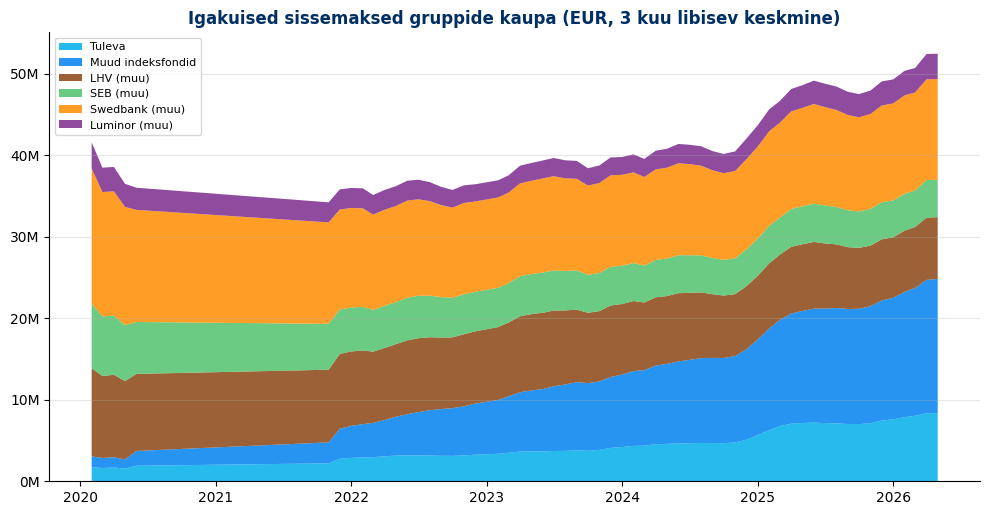

In [8]:
# Stacked area chart — contributions by group (3-month rolling average)
pivot = gdf.pivot_table(index='period_start', columns='group', values='amount', fill_value=0)
pivot = pivot.reindex(columns=GROUP_ORDER)
pivot_smooth = pivot.rolling(ROLLING_WINDOW, center=True).mean().dropna()

fig, ax = plt.subplots(figsize=FB_SIZE)
ax.stackplot(pivot_smooth.index, [pivot_smooth[g] / 1e6 for g in GROUP_ORDER],
             labels=GROUP_ORDER, colors=[GROUP_COLORS[g] for g in GROUP_ORDER], alpha=0.85)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}M'))
ax.set_title('Igakuised sissemaksed gruppide kaupa (EUR, 3 kuu libisev keskmine)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(loc='upper left', fontsize=8)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

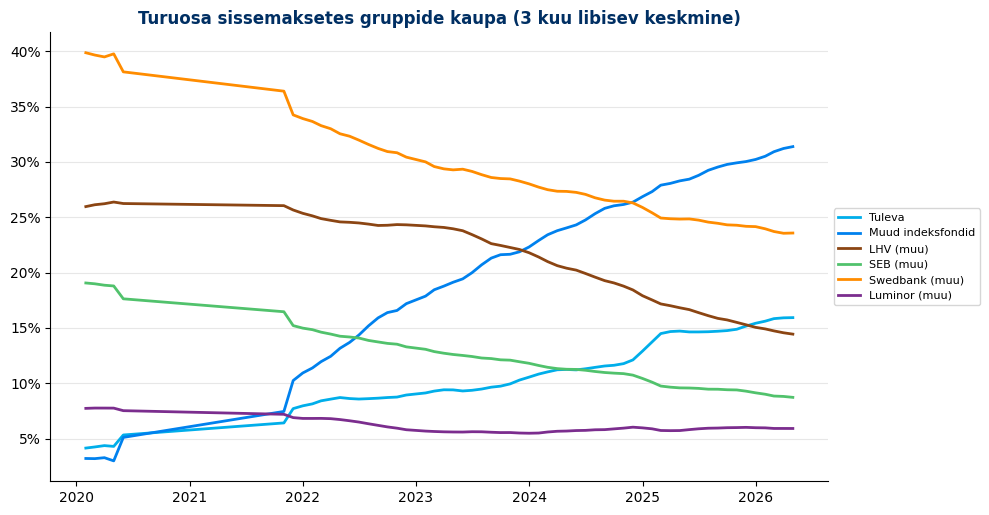

In [9]:
# Market share by group (3-month rolling average)
share_pivot = pivot.div(pivot.sum(axis=1), axis=0) * 100
share_smooth = share_pivot.rolling(ROLLING_WINDOW, center=True).mean().dropna()

fig, ax = plt.subplots(figsize=FB_SIZE)
for group in GROUP_ORDER:
    ax.plot(share_smooth.index, share_smooth[group], label=group, color=GROUP_COLORS[group], linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.set_title('Turuosa sissemaksetes gruppide kaupa (3 kuu libisev keskmine)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(loc='center left', fontsize=8, bbox_to_anchor=(1, 0.5))
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

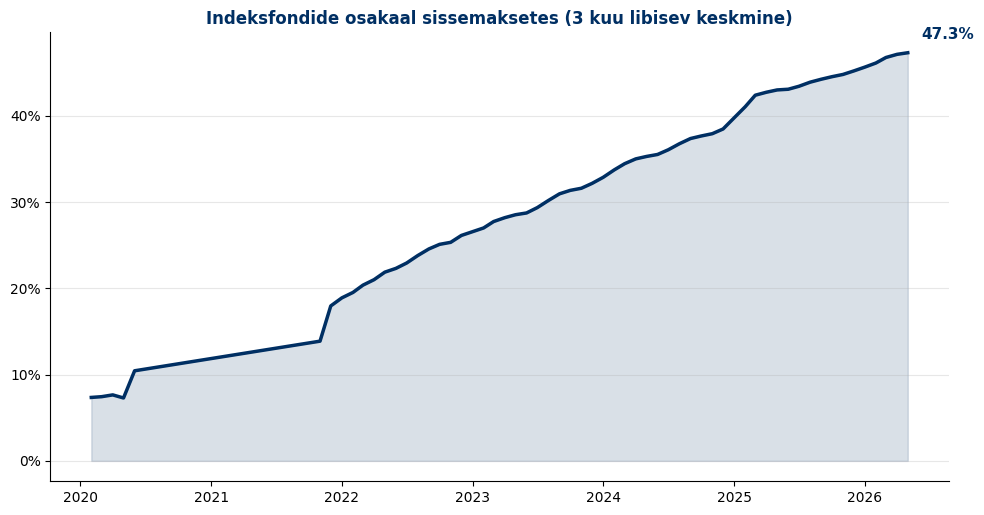

In [10]:
# Combined index fund share over time (Tuleva + other index), 3-month rolling average
index_share_smooth = share_smooth[['Tuleva', 'Muud indeksfondid']].sum(axis=1)

fig, ax = plt.subplots(figsize=FB_SIZE)
ax.plot(index_share_smooth.index, index_share_smooth, color=TULEVA_NAVY, linewidth=2.5)
ax.fill_between(index_share_smooth.index, index_share_smooth, alpha=0.15, color=TULEVA_NAVY)

# Annotate latest value
ax.annotate(f"{index_share_smooth.iloc[-1]:.1f}%", xy=(index_share_smooth.index[-1], index_share_smooth.iloc[-1]),
            fontsize=11, fontweight='bold', color=TULEVA_NAVY,
            xytext=(10, 10), textcoords='offset points')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.set_title('Indeksfondide osakaal sissemaksetes (3 kuu libisev keskmine)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

## Sissemaksed fondihalduri kaupa

In [11]:
mdf = df.groupby(['period_start', 'manager']).agg(amount=('amount', 'sum'), individuals=('individuals', 'sum')).reset_index()

print("Manager-level data ready:", mdf['manager'].unique().tolist())

Manager-level data ready: ['LHV', 'Luminor', 'SEB', 'Swedbank', 'Tuleva']


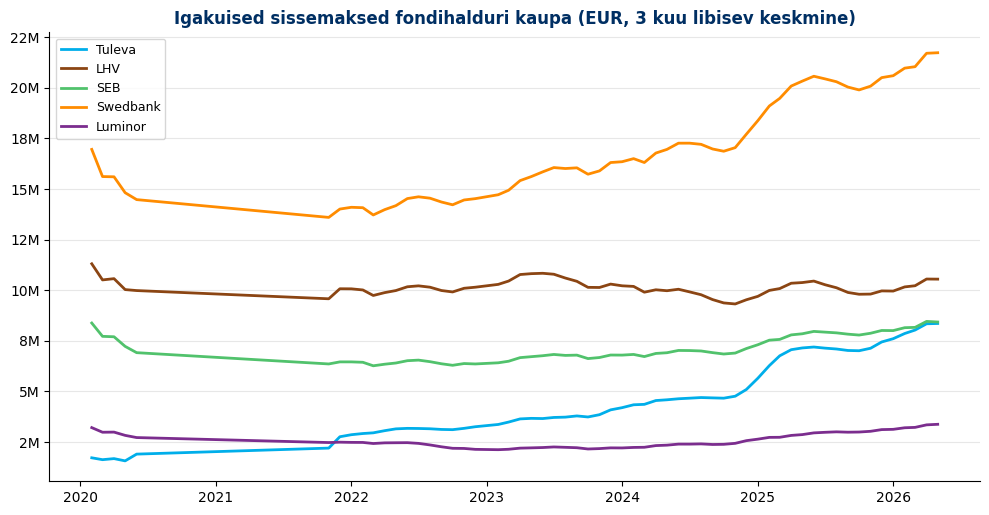

In [12]:
# Monthly contributions by fund manager (3-month rolling average)
fig, ax = plt.subplots(figsize=FB_SIZE)
for manager in MANAGER_ORDER:
    d = mdf[mdf['manager'] == manager].sort_values('period_start')
    smoothed = d['amount'].rolling(ROLLING_WINDOW, center=True).mean()
    ax.plot(d['period_start'], smoothed / 1e6, label=manager, color=COMPETITOR_COLORS[manager], linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}M'))
ax.set_title('Igakuised sissemaksed fondihalduri kaupa (EUR, 3 kuu libisev keskmine)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

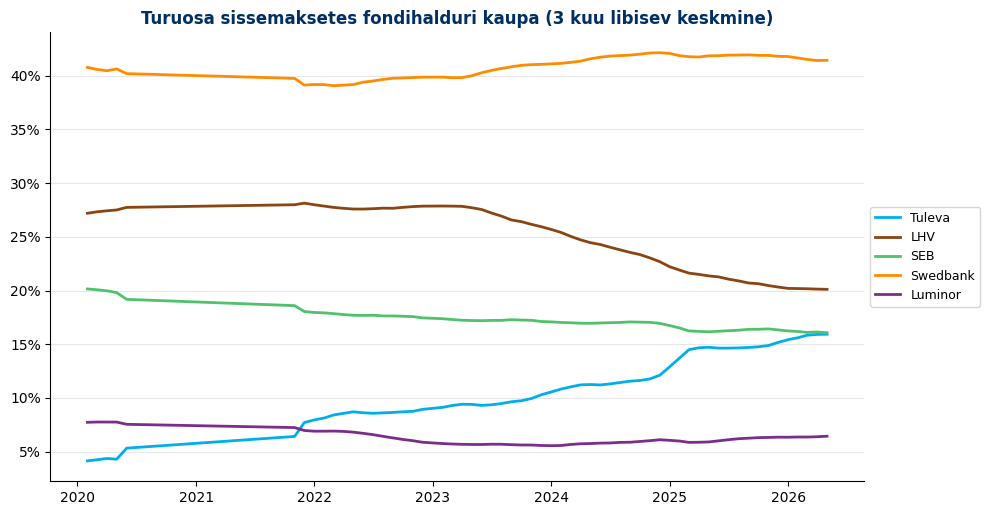

In [13]:
# Market share by fund manager (3-month rolling average)
mgr_pivot = mdf.pivot_table(index='period_start', columns='manager', values='amount', fill_value=0)
mgr_share = mgr_pivot.div(mgr_pivot.sum(axis=1), axis=0) * 100
mgr_share_smooth = mgr_share.rolling(ROLLING_WINDOW, center=True).mean().dropna()

fig, ax = plt.subplots(figsize=FB_SIZE)
for manager in MANAGER_ORDER:
    ax.plot(mgr_share_smooth.index, mgr_share_smooth[manager], label=manager, color=COMPETITOR_COLORS[manager], linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
ax.set_title('Turuosa sissemaksetes fondihalduri kaupa (3 kuu libisev keskmine)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(loc='center left', fontsize=9, bbox_to_anchor=(1, 0.5))
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

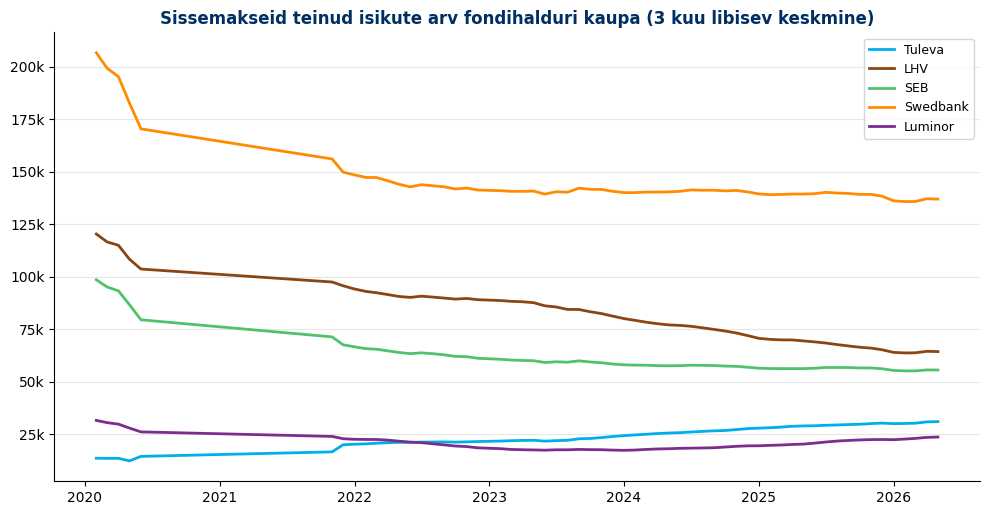

In [14]:
# Individuals by fund manager (3-month rolling average)
fig, ax = plt.subplots(figsize=FB_SIZE)
for manager in MANAGER_ORDER:
    d = mdf[mdf['manager'] == manager].sort_values('period_start')
    smoothed = d['individuals'].rolling(ROLLING_WINDOW, center=True).mean()
    ax.plot(d['period_start'], smoothed / 1000, label=manager, color=COMPETITOR_COLORS[manager], linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}k'))
ax.set_title('Sissemakseid teinud isikute arv fondihalduri kaupa (3 kuu libisev keskmine)', fontsize=12, fontweight='bold', color=TULEVA_NAVY)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()